# Forecast demo
Here we load the trained Aardvark Weather model and produce a global and station forecast using the sample data. 

## Phase 0 Walkthrough Notes

This notebook can inspect the forecast code path locally. Full Aardvark model inference is skipped unless CUDA and downloaded trained weights are both available, because the reference model code hard-codes CUDA internally.

In [30]:
import pickle

import numpy as np
from matplotlib import pyplot as plt
import matplotlib
import torch

from weather_research.aardvark_local import (
    LocalConvCNPWeatherE2E,
    move_tensors_to_device,
    redirect_cuda_to_device,
)
from weather_research.phase0 import (
    AARDVARK_DATA_DIR,
    AARDVARK_TRAINED_MODELS_DIR,
    choose_torch_device,
    require_path,
    load_torch_pickle_cpu,
)

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"


Check a GPU is available

In [31]:
DEVICE = choose_torch_device()
HAS_AARDVARK_WEIGHTS = AARDVARK_TRAINED_MODELS_DIR.exists()
CAN_RUN_AARDVARK_MODEL = HAS_AARDVARK_WEIGHTS
print(f"Local torch device preference: {DEVICE}")
print(f"Aardvark trained weights present: {HAS_AARDVARK_WEIGHTS}")
if not CAN_RUN_AARDVARK_MODEL:
    print("Aardvark weights are missing, so model inference cannot run.")


Local torch device preference: mps
Aardvark trained weights present: True


## Generate predictions

Load the sample data (for a detailed analysis and visualisation of the contents of this dataset see data_demo.ipynb)

In [32]:
sample_data_path = require_path(AARDVARK_DATA_DIR / "sample_data_final.pkl", "Aardvark sample data")
data = load_torch_pickle_cpu(sample_data_path)
print(f"Loaded {sample_data_path}")
print(data.keys())
if CAN_RUN_AARDVARK_MODEL:
    data = move_tensors_to_device(data, DEVICE)
    print(f"Moved sample tensors to {DEVICE}")


Loaded /Users/ewencheung/Documents/GitHub/Weather-Research/Reference-Repo-aardvark-weather-public-main/data/sample_data_final.pkl
dict_keys(['assimilation', 'forecast', 'downscaling', 'y_target'])
Moved sample tensors to mps


In [33]:
# Aardvark sample structure check: this runs locally without model weights.
print("Assimilation sources:", len(data["assimilation"]))
print("Forecast keys:", data["forecast"].keys())
print("Downscaling keys:", data["downscaling"].keys())
for key in ["hirs_current", "amsua_current", "amsub_current", "iasi_current", "ascat_current"]:
    value = data["assimilation"][key]
    print(f"{key}: shape={tuple(value.shape)}, device={value.device}, dtype={value.dtype}")
print("forecast y_context:", tuple(data["forecast"]["y_context"].shape))
print("downscaling x_target:", tuple(data["downscaling"]["x_target"].shape))


Assimilation sources: 26
Forecast keys: dict_keys(['y_context', 'y_target', 'lt'])
Downscaling keys: dict_keys(['x_target', 'alt_target', 'y_target', 'y_context', 'x_context', 'aux_time', 'lt'])
hirs_current: shape=(1, 360, 181, 26), device=mps:0, dtype=torch.float32
amsua_current: shape=(1, 180, 360, 13), device=mps:0, dtype=torch.float32
amsub_current: shape=(1, 360, 181, 12), device=mps:0, dtype=torch.float32
iasi_current: shape=(1, 360, 181, 52), device=mps:0, dtype=torch.float32
ascat_current: shape=(1, 360, 181, 17), device=mps:0, dtype=torch.float32
forecast y_context: (1, 35, 240, 121)
downscaling x_target: (1, 2, 8719)


Load the model to generate predictions at one day leadtime. First select which varaible to generate station forecasts for.

In [34]:
local_forecast_var = "tas"  # Model weights are available for windspeed (ws) and 2m temperature (tas).

if CAN_RUN_AARDVARK_MODEL:
    model = LocalConvCNPWeatherE2E(
        device=DEVICE,
        lead_time=1,
        se_model_path=str(AARDVARK_TRAINED_MODELS_DIR / "encoder"),
        forecast_model_path=str(AARDVARK_TRAINED_MODELS_DIR / "processor"),
        sf_model_path=str(AARDVARK_TRAINED_MODELS_DIR / "decoder" / local_forecast_var) + "/",
        return_gridded=True,
        aux_data_path=str(AARDVARK_DATA_DIR) + "/",
    )
    model.eval()
else:
    model = None


Run the model to generate a forecast the sample data. This outputs the station forecast, gridded forevast and initial state

In [35]:
if model is not None:
    with torch.no_grad(), redirect_cuda_to_device(DEVICE):
        station_forecast, global_forecast, initial_state = model(data)
    print("Ran Aardvark forecast inference")
    print("station_forecast", tuple(station_forecast.shape), station_forecast.device)
    print("global_forecast", tuple(global_forecast.shape), global_forecast.device)
    print("initial_state", tuple(initial_state.shape), initial_state.device)
else:
    station_forecast = global_forecast = initial_state = None
    print("Skipped model(data) because weights are missing.")


Ran Aardvark forecast inference
station_forecast (1, 8719) mps:0
global_forecast (1, 121, 240, 24) mps:0
initial_state (1, 121, 240, 24) mps:0


## Visualise model predictions

First look at the gridded forecasts. Visualise several variables

In [36]:
vars = [
    "u10",
    "v10",
    "t2m",
    "mslp",
    "z200",
    "z500",
    "z700",
    "z850",
    "q200",
    "q500",
    "q700",
    "q850",
    "t200",
    "t500",
    "t700",
    "t850",
    "u200",
    "u500",
    "u700",
    "u850",
    "v200",
    "v500",
    "v700",
    "v850",
]

var_index_mapping = {k: v for v, k in enumerate(vars)}

In [37]:
lon = np.linspace(0, 359, 240)
lat = np.linspace(-90, 90, 121)

Select the variable and data to plot. To plot another variable simply change the variable argument below. 

In [38]:
variable = "u10"
var_index = var_index_mapping[variable]
if initial_state is not None and global_forecast is not None:
    initial_state_var = initial_state[0, ..., var_index].detach().cpu().numpy()
    global_forecast_var = global_forecast[0, ..., var_index].detach().cpu().numpy()
    colorscale_mag = np.max(np.abs(initial_state_var))
else:
    initial_state_var = global_forecast_var = colorscale_mag = None
    print("Skipping gridded forecast extraction because model inference did not run.")


Plot the initial state

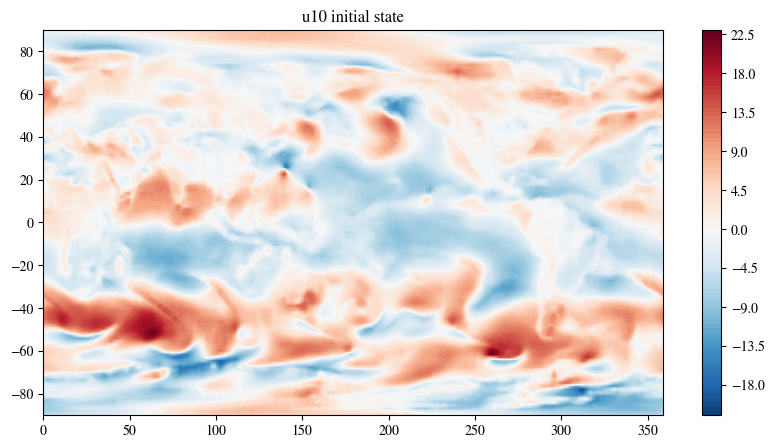

In [39]:
if initial_state_var is None:
    print("Skipping initial-state plot.")
else:
    fig = plt.figure(figsize=(10, 5))
    p = plt.contourf(lon, lat, initial_state_var, levels=100, vmax=colorscale_mag, vmin=-colorscale_mag, cmap="RdBu_r")
    plt.colorbar(p)
    plt.title(f"{variable} initial state")
    plt.show()


Plot the prediction at one day leadtime

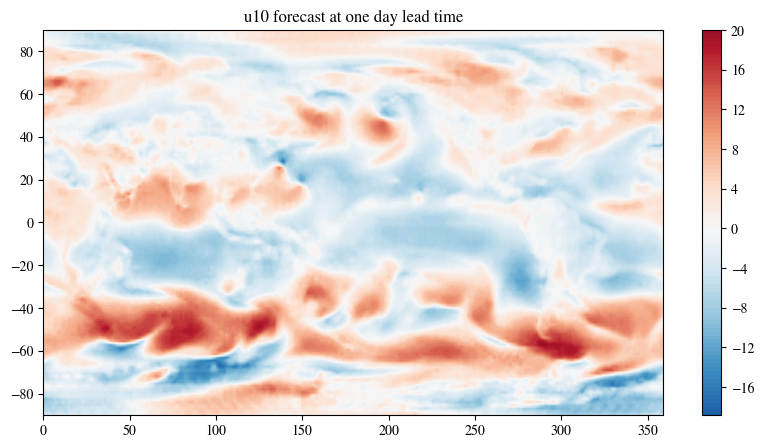

In [40]:
if global_forecast_var is None:
    print("Skipping global forecast plot.")
else:
    fig = plt.figure(figsize=(10, 5))
    p = plt.contourf(lon, lat, global_forecast_var, levels=100, vmax=colorscale_mag, vmin=-colorscale_mag, cmap="RdBu_r")
    plt.colorbar(p)
    plt.title(f"{variable} forecast at one day lead time")
    plt.show()


The model also returns the station forecasts for T2M

In [41]:
STATION_LON_LAT_SF = 360
HADISD_SCALING_FACTOR = 10
mean = np.load(AARDVARK_DATA_DIR / "norm_factors" / f"mean_hadisd_{local_forecast_var}.npy")
std = np.load(AARDVARK_DATA_DIR / "norm_factors" / f"std_hadisd_{local_forecast_var}.npy")


In [42]:
if station_forecast is not None:
    station_forecast = (station_forecast.detach().cpu() * std + mean) * HADISD_SCALING_FACTOR
else:
    print("Skipping station forecast unnormalisation because model inference did not run.")


/var/folders/mf/_jc27bj14xv68vqy0mj9_w540000gn/T/ipykernel_60976/249876387.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  station_forecast = (station_forecast.detach().cpu() * std + mean) * HADISD_SCALING_FACTOR


In [43]:
print("Station forecast shape:", station_forecast.shape if station_forecast is not None else "N/A")

Station forecast shape: torch.Size([1, 8719])


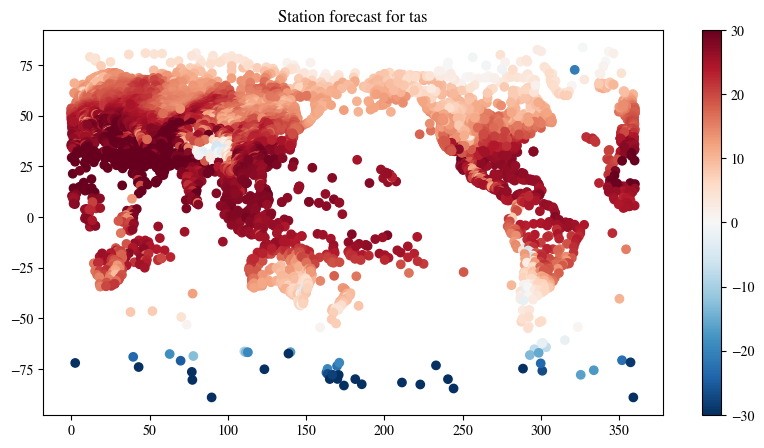

In [44]:
if station_forecast is None:
    print("Skipping station forecast plot.")
else:
    fig = plt.figure(figsize=(10, 5))
    p = plt.scatter(
        data["downscaling"]["x_target"][0, 0, :].detach().cpu() * STATION_LON_LAT_SF,
        data["downscaling"]["x_target"][0, 1, :].detach().cpu() * STATION_LON_LAT_SF,
        c=station_forecast[0, :],
        vmax=30,
        vmin=-30,
        cmap="RdBu_r",
    )
    plt.colorbar(p)
    plt.title(f"Station forecast for {local_forecast_var}")
    plt.show()


# Extra: iterative forecast rollout

For an AIFS-style autoregressive forecast, the clean mental model is:

```text
input:  (t-6h, t0)      -> predict t+6h
input:  (t0,   t+6h)   -> predict t+12h
input:  (t+6h, t+12h)  -> predict t+18h
...
```

So yes: after every forecast step, we slide the time window forward and use the previous prediction as part of the next input.

This Aardvark notebook is not exactly the AIFS interface. Aardvark stores its current gridded model state inside `task["forecast"]["y_context"]`. After each processor step, `process_forecast_output(...)` writes the predicted gridded state back into that context. That gives us the same practical idea: repeatedly feed the latest predicted state back into the processor.

Important limitation for this local Phase 0 notebook: we downloaded only `trained_model/processor/forecast_1`, so the code below reuses that one available processor step 40 times. Treat this as a rollout mechanics demo, not yet a scientifically validated 10-day forecast.

In [45]:
import pandas as pd

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", None)

ROLLOUT_STEP_HOURS = 6
ROLLOUT_DAYS = 10
ROLLOUT_STEPS = (ROLLOUT_DAYS * 24) // ROLLOUT_STEP_HOURS
ROLLOUT_VARIABLE = "t2m"  # Change to u10, v10, mslp, z500, q850, etc.


def fresh_rollout_task():
    """Reload the sample so the rollout starts from the original observation context."""
    task = load_torch_pickle_cpu(sample_data_path)
    return move_tensors_to_device(task, DEVICE)


if model is None:
    rollout_table = pd.DataFrame()
    print("Cannot run iterative rollout because the Aardvark model was not loaded.")
elif ROLLOUT_VARIABLE not in var_index_mapping:
    rollout_table = pd.DataFrame()
    print(f"Unknown rollout variable: {ROLLOUT_VARIABLE}")
else:
    rollout_task = fresh_rollout_task()
    var_index = var_index_mapping[ROLLOUT_VARIABLE]
    rows = []

    with torch.no_grad(), redirect_cuda_to_device(DEVICE):
        # Step 0: encode observations into the initial gridded state.
        encoded_state = model.se_model(rollout_task["assimilation"], film_index=None)
        rollout_task, current_state = model.process_se_output(rollout_task, encoded_state)

        for step in range(1, ROLLOUT_STEPS + 1):
            # We only have forecast_1 locally, so reuse that processor for each +6h demo step.
            pred_diff = model.forecast_model[0](rollout_task["forecast"], film_index=None)
            rollout_task, current_state = model.process_forecast_output(rollout_task, pred_diff)

            field = current_state[0, ..., var_index].detach().cpu()
            rows.append(
                {
                    "step": step,
                    "lead_hours": step * ROLLOUT_STEP_HOURS,
                    "lead_days": round((step * ROLLOUT_STEP_HOURS) / 24, 2),
                    "variable": ROLLOUT_VARIABLE,
                    "shape": tuple(field.shape),
                    "mean": float(field.mean()),
                    "std": float(field.std()),
                    "min": float(field.min()),
                    "max": float(field.max()),
                }
            )

    rollout_table = pd.DataFrame(rows)
    display(rollout_table)


,step,lead_hours,lead_days,variable,shape,mean,std,min,max
0,1,6,0.25,t2m,"(121, 240)",283.408386,21.321985,212.005310,321.111511
1,2,12,0.50,t2m,"(121, 240)",283.580048,20.753029,213.210236,321.821594
2,3,18,0.75,t2m,"(121, 240)",283.652191,20.487223,216.135208,320.845490
3,4,24,1.00,t2m,"(121, 240)",283.721222,20.199299,217.356705,320.119690
4,5,30,1.25,t2m,"(121, 240)",283.770752,19.984077,221.132812,319.571838
5,6,36,1.50,t2m,"(121, 240)",283.877045,19.682531,224.395401,319.628845
6,7,42,1.75,t2m,"(121, 240)",283.966705,19.374397,223.832703,319.506744
7,8,48,2.00,t2m,"(121, 240)",284.048248,19.053957,222.329544,319.127411
8,9,54,2.25,t2m,"(121, 240)",284.149078,18.824139,220.425354,317.426941
9,10,60,2.50,t2m,"(121, 240)",284.148956,18.708981,219.109146,315.989349
